# Work NRLMF in Python

### Notes:

1. The Python codes are now modified to be a package-like format. 

    The files are modified to be compatible with the BiSSGL project: 
    
    `functions.py`, `cv_eval.py`, `PyDTI.py`, `sat_analysis.py`. 


In [1]:
from scipy.special import expit

In [2]:
import numpy as np

random_state = np.random.RandomState(0x0BADCAFE)

Setup for paths and names

In [3]:
import os
import time

PATH_TO_EXP = "/Users/sijianfan/Documents/projects/BiSSGL/datasets/simulations"
PATH_DATA = os.path.join(PATH_TO_EXP, "n_features")

PATH_ARCHIVE = os.path.join(PATH_DATA, "arch_nrlmf")
if not os.path.isdir(PATH_ARCHIVE):
    os.mkdir(PATH_ARCHIVE)

filenames = {"input": "data_{}.gz", "output": "results_nrlmf.gz"}

filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_DATA, filenames["output"])

if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

Import the NRLMF method (under the PyDTI3 package)

In [4]:
import os
import sys
import time
import getopt

# package-qualified imports (preferred)
from PyDTI3 import cv_eval  # if cv_eval exposes functions at top-level
from PyDTI3.functions import *
from PyDTI3.nrlmf import NRLMF
from PyDTI3.new_pairs import novel_prediction_analysis

In [5]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        "train_size": [0.02],
        "n_features": np.arange(50, 401, 50),
        "n_splits": [5],
    }
)

grid_model = ParameterGrid(
    {
        "C_lasso": [0.0],
        "C_group": [0.0],
        "C_ridge": [1e0],
        "lamb": [1e-4, 1e-3, 1e-2],
        "rank": [25],
    }
)

Use `i = 0` as an example

In [6]:
i = 0
par_mdl = grid_model[0]
par_dtst = grid_dataset[0]

In [7]:
from sgimc.utils import mc_split
from sgimc.utils import get_submatrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# from scipy.sparse import coo_matrix


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }

In [8]:
from sgimc.utils import load, save
from sklearn.model_selection import train_test_split

X, Y, R_full, R_noisy = load(filename_input.format(i))
dvlp_size, test_size = 0.9, 0.1
ind_dvlp, ind_test = next(
    mc_split(
        R_full,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)
R_test = get_submatrix(R_full, ind_test)
# prepare the train dataset: take the specified share from the beginnig of the index array
ind_train_all, _ = train_test_split(
    ind_dvlp,
    shuffle=False,
    random_state=random_state,
    test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
)

print(f"R_noisy: {np.unique(R_noisy)}")
print(f"R_full: {np.unique(R_full)}")

R_noisy: [-1.  1.]
R_full: [-1.  1.]


In [9]:
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix

R_train: [-1.  0.  1.]


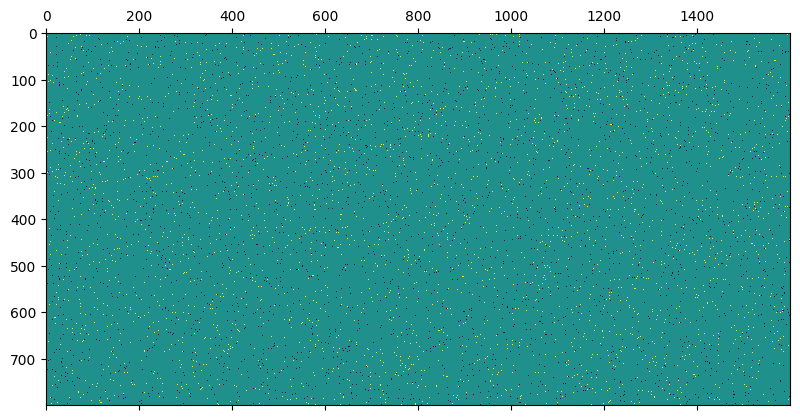

In [25]:
# option 1: (separate missing and negative values)
R_train = get_submatrix(R_noisy, ind_train_all)
R_train = R_train.toarray()
plt.matshow(R_train)
print(f"R_train: {np.unique(R_train)}")
R_train = coo_matrix(R_train).tocsr()

R_train after replacement: [-1.  1.]


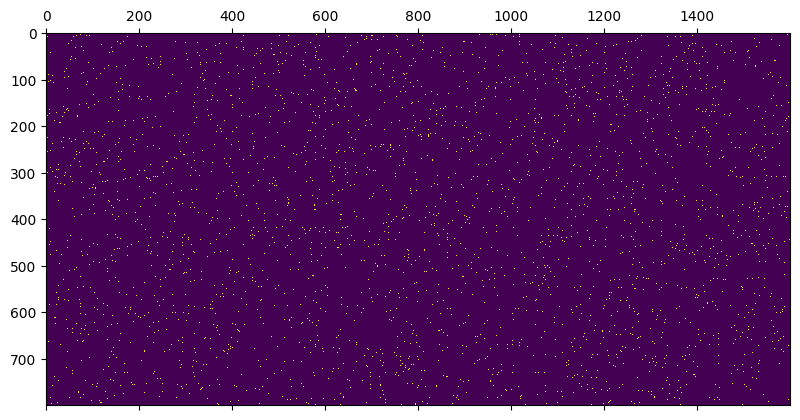

In [11]:
# option 2: (mixed missing and negative values)
R_train = get_submatrix(R_noisy, ind_train_all)
R_train = R_train.toarray()
R_train[R_train == 0] = -1
plt.matshow(R_train)
print(f"R_train after replacement: {np.unique(R_train)}")
R_train = coo_matrix(R_train).tocsr()

In [13]:
def main(
    argv,
    # optional in-memory overrides:
    intMat=None,
    drugMat=None,
    targetMat=None,
    drug_names=None,
    target_names=None,
):
    try:
        opts, args = getopt.getopt(
            argv,
            "m:d:f:c:s:o:n:p",
            [
                "method=",
                "dataset=",
                "data-dir=",
                "cvs=",
                "specify-arg=",
                "method-options=",
                "predict-num=",
                "output-dir=",
            ],
        )
    except getopt.GetoptError as e:
        print("Argument parsing error:", str(e))
        sys.exit()

    data_dir = os.path.join(os.path.pardir, "data")
    output_dir = os.path.join(os.path.pardir, "output")
    cvs, sp_arg, model_settings, predict_num = 1, 1, [], 0

    seeds = [7771, 8367, 22, 1812, 4659]
    # seeds = np.random.choice(10000, 5, replace=False)
    for opt, arg in opts:
        if opt == "--method":
            method = arg
        if opt == "--dataset":
            dataset = arg
        if opt == "--data-dir":
            data_dir = arg
        if opt == "--output-dir":
            output_dir = arg
        if opt == "--cvs":
            cvs = int(arg)
        if opt == "--specify-arg":
            sp_arg = int(arg)
        if opt == "--method-options":
            model_settings = [s.split("=") for s in str(arg).split()]
        if opt == "--predict-num":
            predict_num = int(arg)
    if not os.path.isdir(output_dir):
        os.makedirs(output_dir)

    # default parameters for each methods
    if method == "nrlmf":
        args = {
            "c": 5,
            "K1": 5,
            "K2": 5,
            "r": 50,
            "lambda_d": 0.125,
            "lambda_t": 0.125,
            "alpha": 0.25,
            "beta": 0.125,
            "theta": 0.5,
            "max_iter": 100,
        }

    for key, val in model_settings:
        args[key] = val

    if intMat is None or drugMat is None or targetMat is None:
        if dataset is None or data_dir is None:
            raise ValueError(
                "Either provide in-memory intMat/drugMat/targetMat OR dataset and data_dir"
            )
        intMat, drugMat, targetMat = load_data_from_file(
            dataset, os.path.join(data_dir)
        )
        drug_names, target_names = get_drugs_targets_names(
            dataset, os.path.join(data_dir)
        )

    if predict_num == 0:
        if cvs == 1:  # CV setting CVS1
            X, D, T, cv = intMat, drugMat, targetMat, 1
        if cvs == 2:  # CV setting CVS2
            X, D, T, cv = intMat, drugMat, targetMat, 0
        if cvs == 3:  # CV setting CVS3
            X, D, T, cv = intMat.T, targetMat, drugMat, 0
        cv_data = cross_validation(X, seeds, cv)

    if sp_arg == 0 and predict_num == 0:
        if method == "nrlmf":
            cv_eval.nrlmf_cv_eval(method, dataset, cv_data, X, D, T, cvs, args)

    if sp_arg == 1 or predict_num > 0:
        tic = time.perf_counter()
        if method == "nrlmf":
            model = NRLMF(
                cfix=args["c"],
                K1=args["K1"],
                K2=args["K2"],
                num_factors=args["r"],
                lambda_d=args["lambda_d"],
                lambda_t=args["lambda_t"],
                alpha=args["alpha"],
                beta=args["beta"],
                theta=args["theta"],
                max_iter=args["max_iter"],
            )

        cmd = str(model)
        if predict_num == 0:
            print("Dataset:" + dataset + " CVS:" + str(cvs) + "\n" + cmd)
            aupr_vec, auc_vec = train(model, cv_data, X, D, T)
            aupr_avg, aupr_conf = mean_confidence_interval(aupr_vec)
            auc_avg, auc_conf = mean_confidence_interval(auc_vec)
            print(
                "auc:%.6f, aupr: %.6f, auc_conf:%.6f, aupr_conf:%.6f, Time:%.6f"
                % (auc_avg, aupr_avg, auc_conf, aupr_conf, time.perf_counter() - tic)
            )
            # write_metric_vector_to_file(
            #     auc_vec,
            #     os.path.join(
            #         output_dir, method + "_auc_cvs" + str(cvs) + "_" + dataset + ".txt"
            #     ),
            # )
            # write_metric_vector_to_file(
            #     aupr_vec,
            #     os.path.join(
            #         output_dir, method + "_aupr_cvs" + str(cvs) + "_" + dataset + ".txt"
            #     ),
            # )
        elif predict_num > 0:
            print("Dataset:" + dataset + "\n" + cmd)
            seed = 7771 if method == "cmf" else 22
            model.fix_model(intMat, intMat, drugMat, targetMat, seed)
            fit = model.fix_model(intMat, intMat, drugMat, targetMat, seed)
            x, y = np.where(intMat == 0)
            scores = model.predict_scores(zip(x, y), 5)
            ii = np.argsort(scores)[::-1]
            predict_pairs = [
                (drug_names[x[i]], target_names[y[i]], scores[i])
                for i in ii[:predict_num]
            ]
            new_dti_file = os.path.join(
                output_dir, "_".join([method, dataset, "new_dti.txt"])
            )
            novel_prediction_analysis(
                predict_pairs, new_dti_file, os.path.join(data_dir, "database")
            )

    # write_metric_vector_to_file(
    #     model.U, os.path.join(output_dir, method + "_u" + "_" + dataset + ".txt")
    # )
    # write_metric_vector_to_file(
    #     model.V, os.path.join(output_dir, method + "_v" + "_" + dataset + ".txt")
    # )

    return model.U, model.V

In [26]:
from sklearn.metrics.pairwise import cosine_similarity

simD = cosine_similarity(X[:, :24])
simT = cosine_similarity(Y[:, :24])

# simD = np.eye(simD.shape[0])
# simT = np.eye(simT.shape[0])

In [31]:
# Define argv with test arguments
argv = [
    "--method=nrlmf",
    "--dataset=test",
    "--cvs=1",
    "--method-opt=c=10 r=25",
    "--predict-num=0",
]

In [21]:
np.unique((R_full + 1) / 2)

array([0., 1.])

In [28]:
np.unique((R_train.toarray() + 1) / 2)

array([0. , 0.5, 1. ])

In [32]:
U, V = main(argv, intMat=(R_train.toarray() + 1) / 2, drugMat=simD, targetMat=simT)

Dataset:test CVS:1
Model: NRLMF, c:10, K1:5, K2:5, r:25, lambda_d:0.125, lambda_t:0.125, alpha:0.25, beta:0.125, theta:0.5, max_iter:100
auc:nan, aupr: nan, auc_conf:nan, aupr_conf:nan, Time:97.474215


/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in do

In [33]:
prob_full = expit(simD @ U @ V.T @ simT.T)
prob_test = get_submatrix(prob_full, ind_test)
scores_test = mc_get_scores(R_test, prob_test)
print("Test score:", scores_test)

Test score: {'tn': 32503, 'fn': 30184, 'fp': 31451, 'tp': 33862, 'auc': 0.5150816283966616}


In [68]:
print(scores_test)

{'tn': 41903, 'fn': 23877, 'fp': 22025, 'tp': 40195, 'auc': 0.6517407701719122}
